# 02 — Statistical Process Control (SPC)

## 🎯 Objective
Analyze process stability using Statistical Process Control (SPC) techniques and evaluate how process variability relates to defect generation.

## 🧠 Context
In industrial environments, reducing variability is key to improving product quality. While exploratory analysis helps identify important variables, SPC allows us to monitor process behavior over time and detect instability patterns that may lead to defects.

This notebook focuses on applying control charts to the most relevant process variables identified previously, using SPC as a diagnostic tool for defect generation.

## 📌 Approach
- Use top 5 most relevant process variables (from Notebook 01)
- Apply Individuals and Moving Range (I-MR) control charts
- Identify out-of-control signals
- Relate process instability to defect occurrence

In [3]:
# Library import and data reading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
sns.set_palette("viridis")

df = pd.read_csv("data/raw/faults.csv")
df.shape

(1941, 34)

## 🔧 Data Preparation

To apply Statistical Process Control (SPC), we focus on the most relevant process variables identified in the previous analysis.

We prepare a working dataset that:
- Includes only the top 5 selected features
- Preserves defect information
- Ensures proper observation order for control chart analysis

In [4]:
selected_features = ['Y_Maximum', 'Y_Minimum', 'Sum_of_Luminosity', 'Pixels_Areas', 'Y_Perimeter']

defect_cols_names = df.columns[-7:]

df_spc = df[selected_features + list(defect_cols_names)].copy()
df_spc = df_spc.reset_index(drop=True)

df_spc.head()

,Y_Maximum,Y_Minimum,Sum_of_Luminosity,Pixels_Areas,Y_Perimeter,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,270944,270900,24220,267,44,1,0,0,0,0,0,0
1,2538108,2538079,11397,108,30,1,0,0,0,0,0,0
2,1553931,1553913,7972,71,19,1,0,0,0,0,0,0
3,369415,369370,18996,176,45,1,0,0,0,0,0,0
4,498335,498078,246930,2409,260,1,0,0,0,0,0,0


Selected features are based on the previous exploratory analysis.

## I-MR Control Chart

We use an Individuals and Moving Range (I-MR) chart to evaluate process stability for a selected variable.

The Individuals chart shows the value of each observation along with control limits based on process variation.  
The Moving Range chart captures the variation between consecutive observations.

Points outside control limits indicate potential process instability (out-of-control signals).

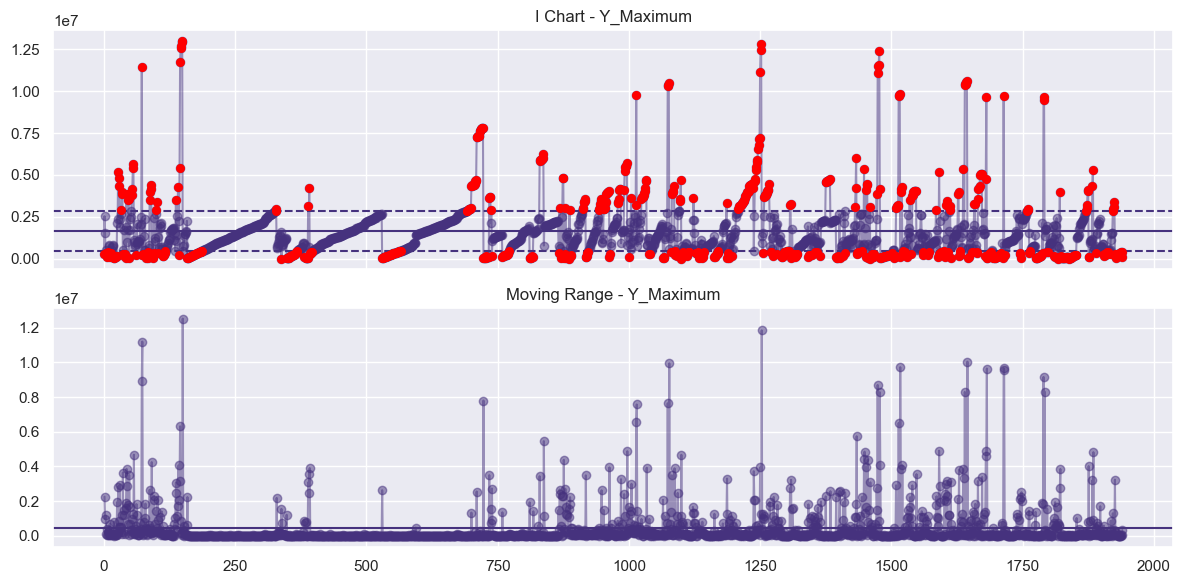

In [28]:
# I Chart and Moving Range Chart for the first selected feature

col = selected_features[0]

x = df_spc[col]

mean_x = x.mean()
mr = x.diff().abs()
mr_mean = mr[1:].mean()

ucl_x = mean_x + 2.66 * mr_mean
lcl_x = mean_x - 2.66 * mr_mean

ooc = (x > ucl_x) | (x < lcl_x)

fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=True)

ax[0].plot(x.values, marker='o', alpha=0.5)
ax[0].scatter(np.where(ooc)[0], x[ooc], color='red', s=30, zorder=3)
ax[0].axhline(mean_x)
ax[0].axhline(ucl_x, linestyle='--')
ax[0].axhline(lcl_x, linestyle='--')
ax[0].set_title(f"I Chart - {col}")

ax[1].plot(mr.values, marker='o', alpha=0.5)
ax[1].axhline(mr_mean)
ax[1].set_title(f"Moving Range - {col}")

plt.tight_layout()
plt.show()

## Defect Distribution vs Process Stability

Since all observations correspond to defective products, we analyze how process stability affects the type of defects generated.

We compare the distribution of defect types between:
- In-control observations
- Out-of-control observations

This allows us to evaluate whether process instability is associated with specific defect patterns.

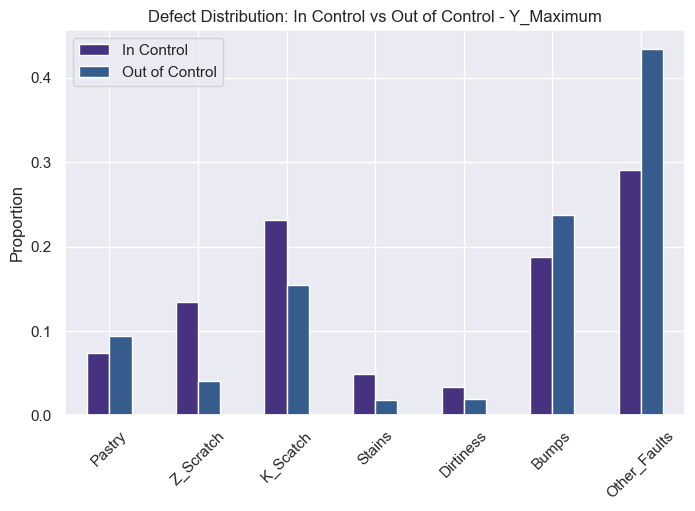

In [30]:
ooc_mask = ooc

defect_ooc = df_spc.loc[ooc_mask, defect_cols_names].sum()
defect_ic = df_spc.loc[~ooc_mask, defect_cols_names].sum()

defect_ooc_pct = defect_ooc / defect_ooc.sum()
defect_ic_pct = defect_ic / defect_ic.sum()

comparison = pd.DataFrame({
    "In Control": defect_ic_pct,
    "Out of Control": defect_ooc_pct
}).fillna(0)

comparison

comparison.plot(kind="bar", figsize=(8,5))
plt.title(f"Defect Distribution: In Control vs Out of Control - {col}")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

## Engineering insight

Analysis for the Y_maximum shows that out of control points are related to the defects Bumps and Ohter_Faults

## SPC Analysis Across Selected Variables

We extend the SPC analysis to all selected variables to evaluate how process instability affects defect distribution across different process dimensions.

For each variable:
- Control limits are computed using I-MR methodology
- Out-of-control observations are identified
- Defect distributions are compared between stable and unstable conditions

In [16]:
results = {}

for col in selected_features:
    
    x = df_spc[col]
    
    mean_x = x.mean()
    mr = x.diff().abs()
    mr_mean = mr[1:].mean()
    
    ucl = mean_x + 2.66 * mr_mean
    lcl = mean_x - 2.66 * mr_mean
    
    ooc = (x > ucl) | (x < lcl)
    
    defect_ooc = df_spc.loc[ooc, defect_cols_names].sum()
    defect_ic = df_spc.loc[~ooc, defect_cols_names].sum()
    
    defect_ooc_pct = defect_ooc / defect_ooc.sum()
    defect_ic_pct = defect_ic / defect_ic.sum()
    
    comparison = pd.DataFrame({
        "In Control": defect_ic_pct,
        "Out of Control": defect_ooc_pct
    }).fillna(0)
    
    results[col] = comparison

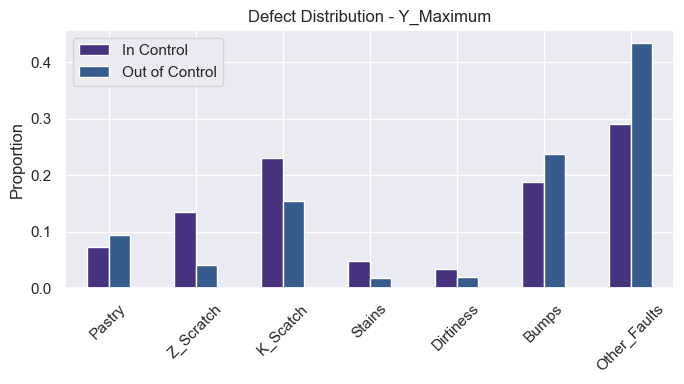

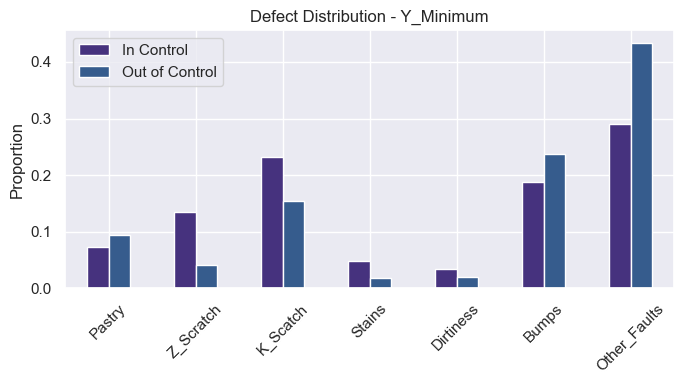

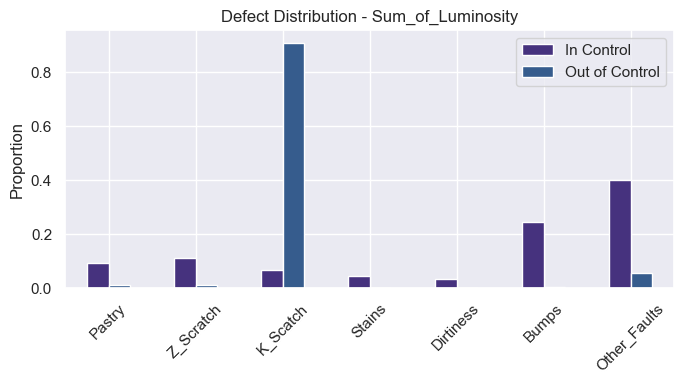

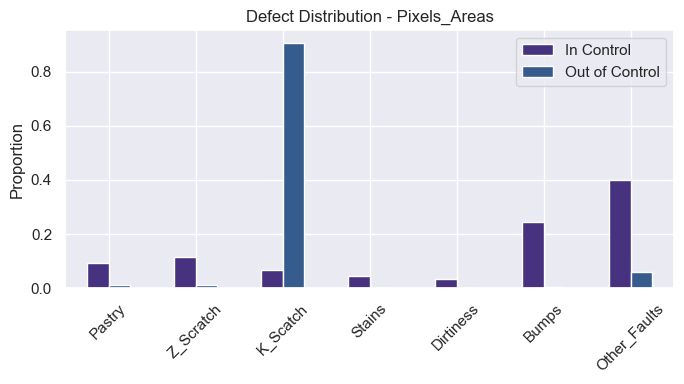

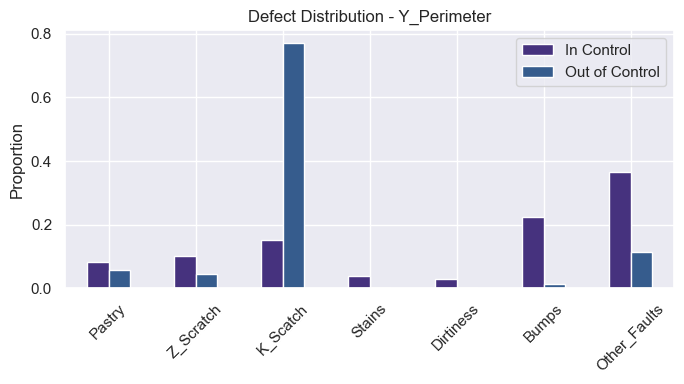

In [17]:
for col, comp in results.items():
    
    comp.plot(kind="bar", figsize=(7,4))
    plt.title(f"Defect Distribution - {col}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Conclusions and Business Insights

The SPC analysis reveals that process instability does not uniformly increase defect occurrence, but instead changes the distribution of defect types.

Across the analyzed variables, out-of-control conditions are associated with a higher proportion of complex and less structured defects (e.g., "Other_Faults" and "Bumps"), suggesting that process variability introduces unpredictable failure modes.

In contrast, certain defects (e.g., scratches) are more frequent under stable conditions, indicating that they are likely driven by specific, repeatable causes rather than overall process instability.

These findings suggest the presence of two distinct regimes:
- Stable process: dominated by structured and repeatable defects
- Unstable process: dominated by complex and variable defect patterns

From a process improvement perspective, this implies that:
- Reducing variability (SPC control) may decrease complex defects
- Targeted interventions are required for defects that persist under stable conditions

This analysis demonstrates how SPC can be integrated with data analysis to move beyond monitoring and towards actionable process insights.